In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score
from sklearn.pipeline import Pipeline
import xgboost as xgb
import optuna
import joblib
import warnings
warnings.filterwarnings('ignore')



In [16]:
# 1) Load Data (replace with your dataset)
# ======================
# Example dataset
data = {
    "age": [25, 32, 47, 51, 62, 23, 44, 36, 52, 48],
    "income": [50000, 60000, 80000, 72000, 91000, 40000, 67000, 58000, 95000, 62000],
    "city": ["Hyd", "Bang", "Pune", "Hyd", "Mumbai", "Chennai", "Pune", "Bang", "Mumbai", "Chennai"],
    "target": [0, 1, 1, 0, 1, 0, 1, 0, 1, 0]
}
df = pd.DataFrame(data)

X = df.drop("target", axis=1)
y = df["target"]


In [17]:
# ======================
# 2) Encode Categorical Columns with LabelEncoder
# ======================
cat_cols = X.select_dtypes(include=["object"]).columns
le_dict = {}  # to save encoders for later use
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    le_dict[col] = le


In [18]:
# ======================
# 3) Train / Validation / Test Split
# ======================
# 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5,
                                                 random_state=42)



In [19]:
# ======================
# 4) Build Pipeline (MinMaxScaler + XGBoost)
# ======================
pipeline = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])



In [20]:
# ======================
# 5) Fit Baseline Model on Train
# ======================
pipeline.fit(X_train, y_train)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


Validation Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Validation F1 (macro): 0.0
Validation ROC AUC: nan


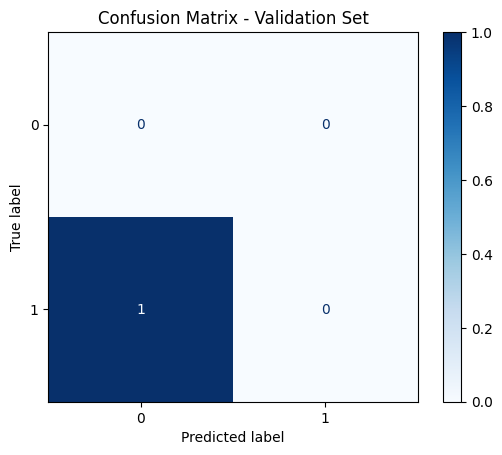

In [21]:
# ======================
# 6) Validate on Validation Set
# ======================
y_val_pred = pipeline.predict(X_val)              # predicted classes
y_val_proba = pipeline.predict_proba(X_val)[:, 1]  # predicted probability of class 1

print("Validation Report:")
print(classification_report(y_val, y_val_pred))
print("Validation F1 (macro):", f1_score(y_val, y_val_pred, average="macro"))
print("Validation ROC AUC:", roc_auc_score(y_val, y_val_proba))

# Confusion Matrix
cm_val = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm_val).plot(cmap="Blues")
plt.title("Confusion Matrix - Validation Set")
plt.show()

In [22]:
# ======================
# 7) Hyperparameter Tuning with Optuna
# ======================
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }
    model = Pipeline([
        ("scaler", MinMaxScaler()),
        ("clf", xgb.XGBClassifier(**params, use_label_encoder=False, eval_metric='logloss', random_state=42))
    ])
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    return np.mean(scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)  # increase trials for better tuning
print("Best Hyperparameters:", study.best_params)


[I 2025-09-29 12:53:01,098] A new study created in memory with name: no-name-178900e2-a74f-4d9e-af7b-8c67a2d76e34
[I 2025-09-29 12:53:01,223] Trial 0 finished with value: 0.37777777777777777 and parameters: {'n_estimators': 198, 'max_depth': 7, 'learning_rate': 0.19693694298828246, 'subsample': 0.9580525431676046, 'colsample_bytree': 0.559097629662614, 'gamma': 0.760064596689593, 'reg_alpha': 4.710484023562789, 'reg_lambda': 3.8006489264152266}. Best is trial 0 with value: 0.37777777777777777.
[I 2025-09-29 12:53:01,330] Trial 1 finished with value: 0.37777777777777777 and parameters: {'n_estimators': 176, 'max_depth': 10, 'learning_rate': 0.01450769993660807, 'subsample': 0.7284898103156461, 'colsample_bytree': 0.5260664894413746, 'gamma': 4.13866233749839, 'reg_alpha': 3.1978079796791565, 'reg_lambda': 4.3081898385588175}. Best is trial 0 with value: 0.37777777777777777.
[I 2025-09-29 12:53:01,396] Trial 2 finished with value: 0.37777777777777777 and parameters: {'n_estimators': 56, 

Best Hyperparameters: {'n_estimators': 198, 'max_depth': 7, 'learning_rate': 0.19693694298828246, 'subsample': 0.9580525431676046, 'colsample_bytree': 0.559097629662614, 'gamma': 0.760064596689593, 'reg_alpha': 4.710484023562789, 'reg_lambda': 3.8006489264152266}


In [23]:
# ======================
# 8) Train Final Model with Best Params
# ======================
best_params = study.best_params
final_model = Pipeline([
    ("scaler", MinMaxScaler()),
    ("clf", xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', random_state=42))
])

final_model.fit(X_train, y_train)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None


Final Test Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       1.0

    accuracy                           0.00       1.0
   macro avg       0.00      0.00      0.00       1.0
weighted avg       0.00      0.00      0.00       1.0

Final Test F1 (macro): 0.0
Final Test ROC AUC: nan


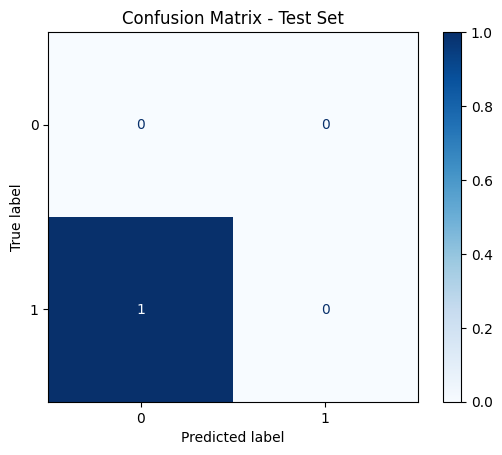

In [24]:
# ======================
# 9) Evaluate on Test Set (Final Check)
# ======================
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print("Final Test Report:")
print(classification_report(y_test, y_test_pred))
print("Final Test F1 (macro):", f1_score(y_test, y_test_pred, average="macro"))
print("Final Test ROC AUC:", roc_auc_score(y_test, y_test_proba))

cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test).plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()


In [25]:
# ======================
# 10) Save Final Pipeline
# ======================
joblib.dump(final_model, "final_xgb_pipeline.joblib")
print("Final XGBoost pipeline saved as final_xgb_pipeline.joblib")

Final XGBoost pipeline saved as final_xgb_pipeline.joblib
